In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.1 MB/s eta 0:00:00


In [ ]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 75.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from nltk.corpus import stopwords

# Descargar stopwords si no están
import nltk
nltk.download('stopwords')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.metrics import classification_report
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Cargar conjunto de datos

In [ ]:
data_df = pd.read_excel("dataset_transformado.xlsx")

In [ ]:
data_df.head()

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description,leisure_label
0,SsWHMAhshPQ,Ovi x Natanael Cano x Aleman x Big Soto - Veng...,2020-08-11 18:00:10,UC648rgJOboZlgcDbW00vTSA,Rancho Humilde,10,2020-08-11 19:00:00,Vengo De Nada|Aleman|Ovi|Big Soto|Trap|Ovi Nat...,741028,113999,4380,5620,https://i.ytimg.com/vi/SsWHMAhshPQ/default.jpg,False,False,Vengo De Nada - Ovi x Natanael Cano x Aleman x...,ocio
1,JOaeND0xUNk,Belinda y Christian Nodal cantan De los besos ...,2020-08-11 13:03:06,UCNVrBkfp4_TG9x4h5kvLeAQ,TV Azteca,24,2020-08-11 19:00:00,tv azteca|videos de tv azteca|azteca uno|en su...,402507,8102,831,803,https://i.ytimg.com/vi/JOaeND0xUNk/default.jpg,False,False,Encendieron el escenario de La Voz. TV AztecaT...,ocio
2,SV91jnGs--s,¿QUIÉN HACE LOS MEJORES NUGGETS? | EL GUZII,2020-08-11 14:57:02,UCuGn3ioftOo6jvHE1YK4Bfw,El Guzii,26,2020-08-11 19:00:00,El Guzii|Guzzi|Guzy|Guzii Style|Recetas Divert...,735044,62188,1053,4100,https://i.ytimg.com/vi/SV91jnGs--s/default.jpg,False,False,Si tienes 10 kg de sobre peso tal vez te haz p...,ocio
3,QgX0zn5nMyk,Martha Figueroa se disculpa públicamente con N...,2020-08-11 10:57:47,UCJPd6seu4JK4PZjVVTWb0QA,Hoy,24,2020-08-11 19:00:00,Televisa|Televisa espectaculos|programa hoy te...,521751,4680,3129,2285,https://i.ytimg.com/vi/QgX0zn5nMyk/default.jpg,False,False,Mira aquí el contenido exclusivo que tenemos p...,ocio
4,cKaM19oAwBM,MAQUILLAJE PARA KIMBERLY LOAIZA✨ RESISTENTE AL...,2020-08-11 16:55:08,UCs5w0QCxsEWz83vuQyOCnuA,Victor Guadarrama,26,2020-08-11 19:00:00,MAQUILLAJE|CELEBS|ARTE|MAKEUP|PESTAÑAS|KIMBERL...,168118,24551,537,782,https://i.ytimg.com/vi/cKaM19oAwBM/default.jpg,False,False,No olvides suscribirte y activar la campanita ...,ocio


In [ ]:
print(f"Tamaño del conjunto de datos: {data_df.shape}")

Tamaño del conjunto de datos: (32442, 17)


# Análisis de datos

## Información

Vemos la información de cada columna

In [ ]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32442 entries, 0 to 32441
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   video_id           32442 non-null  object        
 1   title              32442 non-null  object        
 2   publishedAt        32442 non-null  datetime64[ns]
 3   channelId          32442 non-null  object        
 4   channelTitle       32442 non-null  object        
 5   categoryId         32442 non-null  int64         
 6   trending_date      32442 non-null  datetime64[ns]
 7   tags               32442 non-null  object        
 8   view_count         32442 non-null  int64         
 9   likes              32442 non-null  int64         
 10  dislikes           32442 non-null  int64         
 11  comment_count      32442 non-null  int64         
 12  thumbnail_link     32442 non-null  object        
 13  comments_disabled  32442 non-null  bool          
 14  rating

## Datos duplicados

In [ ]:
duplicados = data_df.duplicated().sum()
print(f"Datos duplicados: {duplicados}")

Datos duplicados: 0


## Datos faltantes

In [ ]:
datos_nulos_per = data_df.isnull().mean() * 100
datos_nulos_per[datos_nulos_per > 0]

,0
description,4.213674


* No se tienen el 4% de las descripciones

# Distribución de las clases

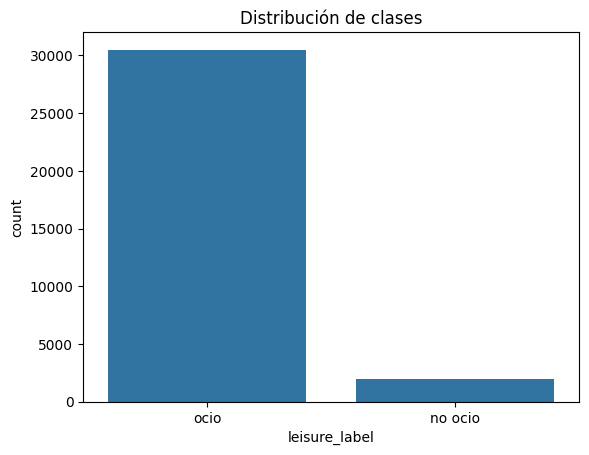

In [ ]:
sns.countplot(x='leisure_label', data=data_df)
plt.title('Distribución de clases')
plt.show()

Se puede observar que el conjunto de datos está altamente desbalanceado. Veamos los valores exactos

In [ ]:
data_df['leisure_label'].value_counts()

,count
leisure_label,
ocio,30513
no ocio,1929


## Distribución de descripciones

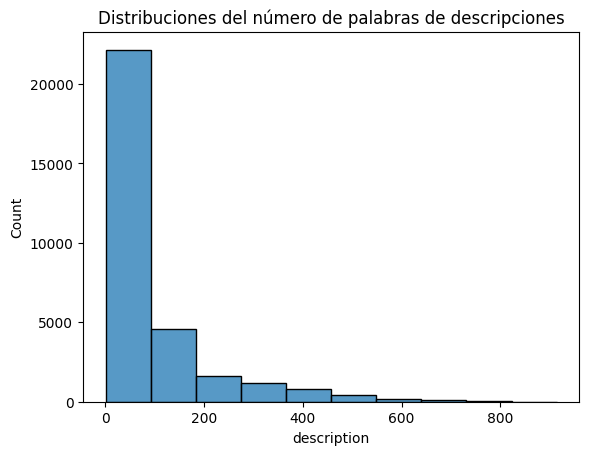

In [ ]:
longitudes = data_df['description'].str.split().str.len()
sns.histplot(longitudes, bins=10)
plt.title('Distribuciones del número de palabras de descripciones')
plt.show()

In [ ]:
longitudes.describe()

,description
count,31075.000000
mean,94.829445
std,114.414725
min,1.000000
25%,29.000000
50%,53.000000
75%,105.000000
max,914.000000


Se puede observar lo siguiente:

* El promedio de número de palabras de las descripciones iniciales es ~95.
* El 75% de las descripciones tienen menos de 105 palabras.
* Algunas descripciones tienen hasta 914 palabras.
* Se tienen descripciones de una sola palabra.

## Distribuciones de descripciones por clase

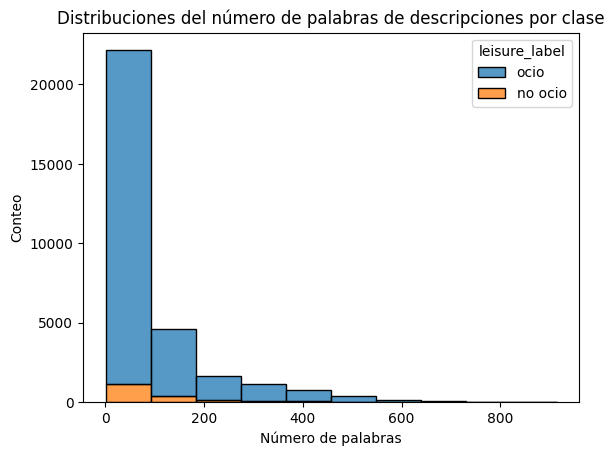

In [ ]:
sns.histplot(data=data_df, x=longitudes, hue='leisure_label', bins=10, multiple='stack')
plt.title('Distribuciones del número de palabras de descripciones por clase')
plt.xlabel('Número de palabras')
plt.ylabel('Conteo')
plt.show()


La proporción de palabras por clase se mantienen.

## Distribución de títulos

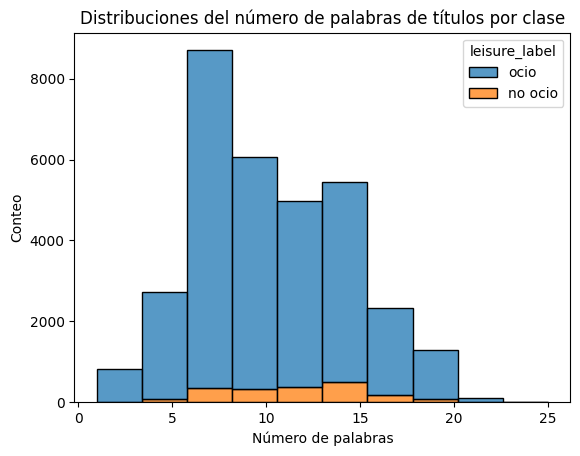

In [ ]:
longitudes_titulos = data_df['title'].str.split().str.len()
sns.histplot(data=data_df, x=longitudes_titulos, hue='leisure_label', bins=10, multiple='stack')
plt.title('Distribuciones del número de palabras de títulos por clase')
plt.xlabel('Número de palabras')
plt.ylabel('Conteo')
plt.show()


In [ ]:
estadisticas_por_clase = data_df.groupby('leisure_label')['title'].apply(lambda x: x.str.split().str.len().describe())
estadisticas_por_clase


leisure_label       
no ocio        count     1929.000000
               mean        11.463453
               std          3.642596
               min          2.000000
               25%          9.000000
               50%         12.000000
               75%         14.000000
               max         22.000000
ocio           count    30513.000000
               mean        10.132108
               std          3.978461
               min          1.000000
               25%          7.000000
               50%         10.000000
               75%         13.000000
               max         25.000000
Name: title, dtype: float64

* Se tienen títulos menores a 30 palabras
* En promedio las palabras por titulo es de ~10.
* Se tienen títulos de solo una palabra.

## Combinamos título con descripción

In [ ]:
data_df['text_combined'] = data_df['title'] + ' ' + data_df['description'].fillna("")
data_df.head()

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description,leisure_label,text_combined
0,SsWHMAhshPQ,Ovi x Natanael Cano x Aleman x Big Soto - Veng...,2020-08-11 18:00:10,UC648rgJOboZlgcDbW00vTSA,Rancho Humilde,10,2020-08-11 19:00:00,Vengo De Nada|Aleman|Ovi|Big Soto|Trap|Ovi Nat...,741028,113999,4380,5620,https://i.ytimg.com/vi/SsWHMAhshPQ/default.jpg,False,False,Vengo De Nada - Ovi x Natanael Cano x Aleman x...,ocio,Ovi x Natanael Cano x Aleman x Big Soto - Veng...
1,JOaeND0xUNk,Belinda y Christian Nodal cantan De los besos ...,2020-08-11 13:03:06,UCNVrBkfp4_TG9x4h5kvLeAQ,TV Azteca,24,2020-08-11 19:00:00,tv azteca|videos de tv azteca|azteca uno|en su...,402507,8102,831,803,https://i.ytimg.com/vi/JOaeND0xUNk/default.jpg,False,False,Encendieron el escenario de La Voz. TV AztecaT...,ocio,Belinda y Christian Nodal cantan De los besos ...
2,SV91jnGs--s,¿QUIÉN HACE LOS MEJORES NUGGETS? | EL GUZII,2020-08-11 14:57:02,UCuGn3ioftOo6jvHE1YK4Bfw,El Guzii,26,2020-08-11 19:00:00,El Guzii|Guzzi|Guzy|Guzii Style|Recetas Divert...,735044,62188,1053,4100,https://i.ytimg.com/vi/SV91jnGs--s/default.jpg,False,False,Si tienes 10 kg de sobre peso tal vez te haz p...,ocio,¿QUIÉN HACE LOS MEJORES NUGGETS? | EL GUZII Si...
3,QgX0zn5nMyk,Martha Figueroa se disculpa públicamente con N...,2020-08-11 10:57:47,UCJPd6seu4JK4PZjVVTWb0QA,Hoy,24,2020-08-11 19:00:00,Televisa|Televisa espectaculos|programa hoy te...,521751,4680,3129,2285,https://i.ytimg.com/vi/QgX0zn5nMyk/default.jpg,False,False,Mira aquí el contenido exclusivo que tenemos p...,ocio,Martha Figueroa se disculpa públicamente con N...
4,cKaM19oAwBM,MAQUILLAJE PARA KIMBERLY LOAIZA✨ RESISTENTE AL...,2020-08-11 16:55:08,UCs5w0QCxsEWz83vuQyOCnuA,Victor Guadarrama,26,2020-08-11 19:00:00,MAQUILLAJE|CELEBS|ARTE|MAKEUP|PESTAÑAS|KIMBERL...,168118,24551,537,782,https://i.ytimg.com/vi/cKaM19oAwBM/default.jpg,False,False,No olvides suscribirte y activar la campanita ...,ocio,MAQUILLAJE PARA KIMBERLY LOAIZA✨ RESISTENTE AL...


# Preprocesamiento de texto

In [ ]:
import spacy
import unicodedata
from spacy.lang.es.stop_words import STOP_WORDS

# Cargar modelo en español de SpaCy para lematización
nlp = spacy.load('es_core_news_sm')

# Función para eliminar acentos y pasar a minúsculas
def normalizar_texto(texto):
    texto = texto.lower()
    texto = unicodedata.normalize('NFD', texto).encode('ascii', 'ignore').decode('utf-8')
    return texto

# Crear lista de stopwords normalizada (sin acentos)
stopwords_normalizadas = set(normalizar_texto(palabra) for palabra in STOP_WORDS)


def preprocesar_texto(texto):
    # Eliminar URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', ' ', texto)

    # Normalizar texto (minúsculas y sin acentos)
    texto_norm = normalizar_texto(texto)

    # Eliminar puntuación y caracteres no alfabéticos (conservando espacios)
    texto_norm = re.sub(r'[^a-zA-Z\s]', ' ', texto_norm)

    # Tokenizar con spaCy (sin lematizar aquí para mantener la forma limpia)
    doc = nlp(texto_norm)

    # Filtrar tokens cuyo texto normalizado está en stopwords normalizadas
    tokens_filtrados = [token.text for token in doc if token.text not in stopwords_normalizadas and token.text.strip() != '']
    #tokens_lematizados = [token.lemma_ for token in doc if token.lemma_ not in stopwords_normalizadas and token.lemma_.strip() != '']

    return ' '.join(tokens_filtrados)
    #return ' '.join(tokens_lematizados)


def filter_short_texts(df, col = 'preprocessed', min_words=3):
    return df[df[col].str.split().str.len() >= min_words].copy()

# Ejemplo
texto_ejemplo = "Él sabe que él éxito depende de la dedicación, tú puedees."
print(preprocesar_texto(texto_ejemplo))

exito depende dedicacion puedees


In [ ]:
data_df['preprocessed'] = data_df['text_combined'].apply(preprocesar_texto)
data_df.head()

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description,leisure_label,text_combined,preprocessed
0,SsWHMAhshPQ,Ovi x Natanael Cano x Aleman x Big Soto - Veng...,2020-08-11 18:00:10,UC648rgJOboZlgcDbW00vTSA,Rancho Humilde,10,2020-08-11 19:00:00,Vengo De Nada|Aleman|Ovi|Big Soto|Trap|Ovi Nat...,741028,113999,4380,5620,https://i.ytimg.com/vi/SsWHMAhshPQ/default.jpg,False,False,Vengo De Nada - Ovi x Natanael Cano x Aleman x...,ocio,Ovi x Natanael Cano x Aleman x Big Soto - Veng...,ovi x natanael cano x aleman x big soto vengo ...
1,JOaeND0xUNk,Belinda y Christian Nodal cantan De los besos ...,2020-08-11 13:03:06,UCNVrBkfp4_TG9x4h5kvLeAQ,TV Azteca,24,2020-08-11 19:00:00,tv azteca|videos de tv azteca|azteca uno|en su...,402507,8102,831,803,https://i.ytimg.com/vi/JOaeND0xUNk/default.jpg,False,False,Encendieron el escenario de La Voz. TV AztecaT...,ocio,Belinda y Christian Nodal cantan De los besos ...,belinda christian nodal cantan besos di revive...
2,SV91jnGs--s,¿QUIÉN HACE LOS MEJORES NUGGETS? | EL GUZII,2020-08-11 14:57:02,UCuGn3ioftOo6jvHE1YK4Bfw,El Guzii,26,2020-08-11 19:00:00,El Guzii|Guzzi|Guzy|Guzii Style|Recetas Divert...,735044,62188,1053,4100,https://i.ytimg.com/vi/SV91jnGs--s/default.jpg,False,False,Si tienes 10 kg de sobre peso tal vez te haz p...,ocio,¿QUIÉN HACE LOS MEJORES NUGGETS? | EL GUZII Si...,mejores nuggets guzii tienes kg peso haz pregu...
3,QgX0zn5nMyk,Martha Figueroa se disculpa públicamente con N...,2020-08-11 10:57:47,UCJPd6seu4JK4PZjVVTWb0QA,Hoy,24,2020-08-11 19:00:00,Televisa|Televisa espectaculos|programa hoy te...,521751,4680,3129,2285,https://i.ytimg.com/vi/QgX0zn5nMyk/default.jpg,False,False,Mira aquí el contenido exclusivo que tenemos p...,ocio,Martha Figueroa se disculpa públicamente con N...,martha figueroa disculpa publicamente nicolas ...
4,cKaM19oAwBM,MAQUILLAJE PARA KIMBERLY LOAIZA✨ RESISTENTE AL...,2020-08-11 16:55:08,UCs5w0QCxsEWz83vuQyOCnuA,Victor Guadarrama,26,2020-08-11 19:00:00,MAQUILLAJE|CELEBS|ARTE|MAKEUP|PESTAÑAS|KIMBERL...,168118,24551,537,782,https://i.ytimg.com/vi/cKaM19oAwBM/default.jpg,False,False,No olvides suscribirte y activar la campanita ...,ocio,MAQUILLAJE PARA KIMBERLY LOAIZA✨ RESISTENTE AL...,maquillaje kimberly loaiza resistente agua vic...


In [ ]:
filtered_df = filter_short_texts(data_df, 'preprocessed', min_words=3)
filtered_df.head()

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description,leisure_label,text_combined,preprocessed,label
0,SsWHMAhshPQ,Ovi x Natanael Cano x Aleman x Big Soto - Veng...,2020-08-11 18:00:10,UC648rgJOboZlgcDbW00vTSA,Rancho Humilde,10,2020-08-11 19:00:00,Vengo De Nada|Aleman|Ovi|Big Soto|Trap|Ovi Nat...,741028,113999,4380,5620,https://i.ytimg.com/vi/SsWHMAhshPQ/default.jpg,False,False,Vengo De Nada - Ovi x Natanael Cano x Aleman x...,ocio,Ovi x Natanael Cano x Aleman x Big Soto - Veng...,ovi x natanael cano x aleman x big soto vengo ...,1
1,JOaeND0xUNk,Belinda y Christian Nodal cantan De los besos ...,2020-08-11 13:03:06,UCNVrBkfp4_TG9x4h5kvLeAQ,TV Azteca,24,2020-08-11 19:00:00,tv azteca|videos de tv azteca|azteca uno|en su...,402507,8102,831,803,https://i.ytimg.com/vi/JOaeND0xUNk/default.jpg,False,False,Encendieron el escenario de La Voz. TV AztecaT...,ocio,Belinda y Christian Nodal cantan De los besos ...,belinda christian nodal cantan besos di revive...,1
2,SV91jnGs--s,¿QUIÉN HACE LOS MEJORES NUGGETS? | EL GUZII,2020-08-11 14:57:02,UCuGn3ioftOo6jvHE1YK4Bfw,El Guzii,26,2020-08-11 19:00:00,El Guzii|Guzzi|Guzy|Guzii Style|Recetas Divert...,735044,62188,1053,4100,https://i.ytimg.com/vi/SV91jnGs--s/default.jpg,False,False,Si tienes 10 kg de sobre peso tal vez te haz p...,ocio,¿QUIÉN HACE LOS MEJORES NUGGETS? | EL GUZII Si...,mejores nuggets guzii tienes kg peso haz pregu...,1
3,QgX0zn5nMyk,Martha Figueroa se disculpa públicamente con N...,2020-08-11 10:57:47,UCJPd6seu4JK4PZjVVTWb0QA,Hoy,24,2020-08-11 19:00:00,Televisa|Televisa espectaculos|programa hoy te...,521751,4680,3129,2285,https://i.ytimg.com/vi/QgX0zn5nMyk/default.jpg,False,False,Mira aquí el contenido exclusivo que tenemos p...,ocio,Martha Figueroa se disculpa públicamente con N...,martha figueroa disculpa publicamente nicolas ...,1
4,cKaM19oAwBM,MAQUILLAJE PARA KIMBERLY LOAIZA✨ RESISTENTE AL...,2020-08-11 16:55:08,UCs5w0QCxsEWz83vuQyOCnuA,Victor Guadarrama,26,2020-08-11 19:00:00,MAQUILLAJE|CELEBS|ARTE|MAKEUP|PESTAÑAS|KIMBERL...,168118,24551,537,782,https://i.ytimg.com/vi/cKaM19oAwBM/default.jpg,False,False,No olvides suscribirte y activar la campanita ...,ocio,MAQUILLAJE PARA KIMBERLY LOAIZA✨ RESISTENTE AL...,maquillaje kimberly loaiza resistente agua vic...,1


Mostramos algunos textos preprocesados

In [ ]:
for i in range(10):
    print(f'Original: {filtered_df["text_combined"].iloc[i]}')
    print(f'Limpio: {filtered_df["preprocessed"].iloc[i]}')
    print()

Original: Ovi x Natanael Cano x Aleman x Big Soto - Vengo De Nada [Official Video] Vengo De Nada - Ovi x Natanael Cano x Aleman x Big SotoDirected by Lalo The GiantExecutive Producer Jimmy Humildehttp://Instagram.com/Ovi_Oficialhttp://Instagram.com/Natanael_Canohttp://Instagram.com/mxalemanmxhttp://Instagram.com/BigSotorius_x000D_Suscríbete: http://Rancho.lnk.to/RHYoutubeEscucha Vengo De Nada aquí:http://Rancho.lnk.to/VengoDeNada 🎶Paginas Oficiales De Rancho HumildeSpotify: http://Rancho.lnk.to/RHSpotifyInstagram: http://Rancho.lnk.to/InstagramFacebook: http://Rancho.lnk.to/RHFacebook🎧Spotify Playlists:➤ 💪Entre Acordeones: http://Rancho.lnk.to/SpotifyPlaylist1➤ 🚬 420 Smoke Me Out: http://Rancho.lnk.to/SpotifySMOYouTube Playlists 📢📢  | Corridos 2020Natanael Cano: http://Rancho.lnk.to/NCPlaylistLegado 7: http://Rancho.lnk.to/L7PlaylistFuerza Regida: http://Rancho.lnk.to/FRPlaylistEl De La Guitarra: http://Rancho.lnk.to/EdlgPlaylistGrupo Codiciado: http://Rancho.lnk.to/GCPlaylistLos Hijos

## Distribución de textos luego del preprocesamiento

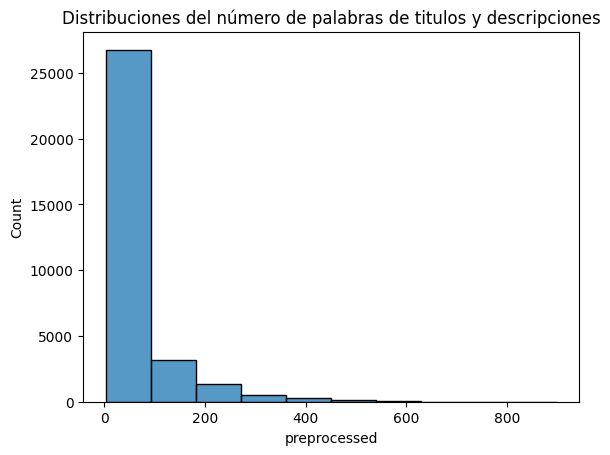

In [ ]:
longitudes_filtrado = filtered_df['preprocessed'].str.split().str.len()
sns.histplot(longitudes_filtrado, bins=10)
plt.title('Distribuciones del número de palabras de titulos y descripciones')
plt.show()

In [ ]:
longitudes_filtrado.describe()

,preprocessed
count,32198.000000
mean,61.135630
std,77.900647
min,3.000000
25%,20.000000
50%,35.000000
75%,63.000000
max,898.000000


Se puede observar lo siguiente:

* El promedio de número de palabras de los textos es de ~60.
* El 75% de los textos tienen menos de 62 palabras.
* Algunas descripciones tienen hasta 803 palabras.
* Se eliminaron los textos con menos de 3 palabras

# Nube de palabras

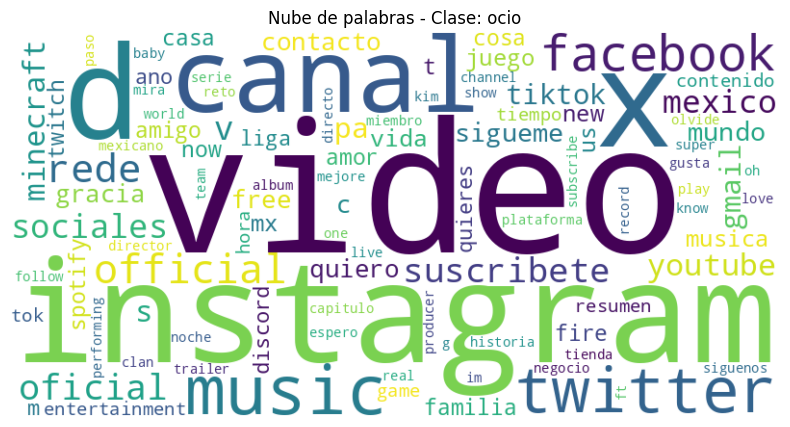

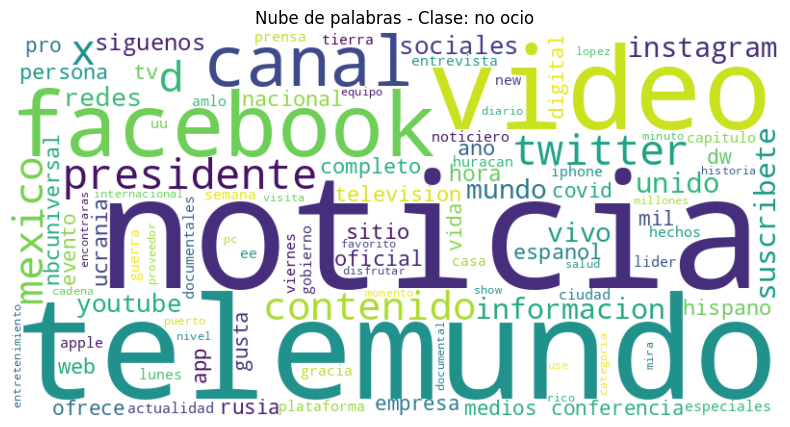

In [ ]:
from wordcloud import WordCloud#, STOPWORDS
import matplotlib.pyplot as plt
# Generar nube de palabras para cada clase
for clase in filtered_df['leisure_label'].unique():
    # Unir todos los textos de la clase en una sola cadena
    texto_clase = ' '.join(filtered_df[filtered_df['leisure_label'] == clase]['preprocessed'])

    # Crear objeto WordCloud
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          collocations=False,
                          #stopwords=STOPWORDS,
                          max_words=100).generate(texto_clase)

    # Mostrar la nube de palabras
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Nube de palabras - Clase: {clase}')
    plt.show()

# Convertir etiquetas a números

In [ ]:
data_df['label'] = data_df['leisure_label'].map({'ocio':1, 'no ocio':0})
data_df['label']

,label
0,1
1,1
2,1
3,1
4,1
...,...
32437,1
32438,1
32439,1
32440,1


In [ ]:
print(data_df.loc[data_df['label'] == 0, ['title', 'description']].values[:10])
print("Ocio")
print(data_df.loc[data_df['label'] == 1, ['title', 'description']].values[:10])

[['Escucho/Analizo a PXNDX por primera vez | ShaunTrack'
  'Bienvenidos a mi sección de vídeo-análisis musical. O, como he bautizado: Shaun-álisis :)Hoy voy a escuchar por primera vez a la banda mexicana de punk rock Pxndx (Panda). Haré un repaso de toda su discografía escuchando un tema de cada disco.Mi nombre es Shaun y llevo más de media vida dedicándome a la música. Soy músico multinstrumentista, productor, compositor y licenciado en Magisterio de Educación Musical. Si te ha gustado este análisis/cover suscríbete para ver más.-------------------------------------------------------------------------------------------------La mayoría de mis vídeos son desmonetizados por Copyright. Si quieres ayudarme a seguir creando contenido en YouTube te invito a apoyarme en PATREON: https://www.patreon.com/shauntrack--------------------------------------------------------------------------------------------------Escucha mi música en SPOTIFY: https://spoti.fi/2Q9y5wb-------------------------------

# Separar textos de variable objetivo

In [ ]:
y = data_df['label'].values
X = data_df['preprocessed'].values

# Particionamiento de textos

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Tamaño del conjunto de datos de entrenamiento: {X_train.shape}')
print(f'Tamaño del conjunto de datos de prueba: {X_test.shape}')

Tamaño del conjunto de datos de entrenamiento: (25953,)
Tamaño del conjunto de datos de prueba: (6489,)


# Tf-Idf

## Modelo Base de Regresión Logística

In [ ]:
# Pipeline con TF-IDF + Regresión logística
pipe_base_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced'))
])

# Entrenar
pipe_base_lr.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

### Predicciones de entrenamiento y prueba

In [ ]:
y_train_pred_base = pipe_base_lr.predict(X_train)
y_test_pred_base = pipe_base_lr.predict(X_test)

### Nombres de clases

In [ ]:
nombres_clases = ['No ocio', 'Ocio']

### Matrices de confusión

In [ ]:
def mostrar_matriz_confusion(conf_matrix, class_names, title='Matriz de confusión'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

### Matriz de confusión para entrenamiento

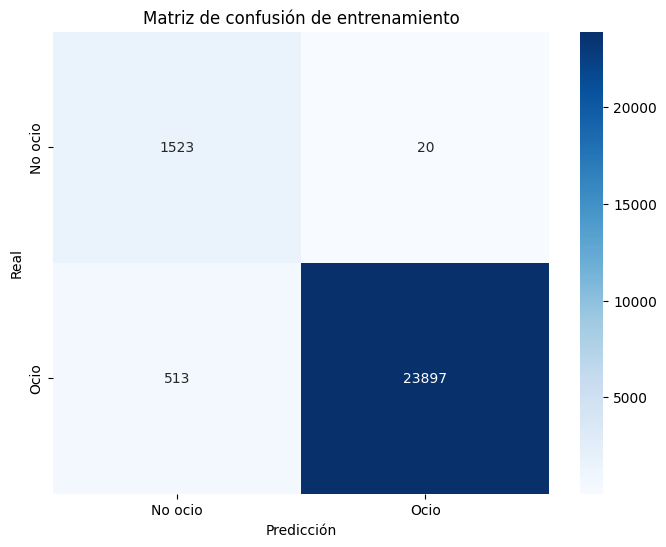

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
cm_train = confusion_matrix(y_train, y_train_pred_base)
mostrar_matriz_confusion(cm_train, nombres_clases, title='Matriz de confusión de entrenamiento')

### Matriz de confusión para prueba

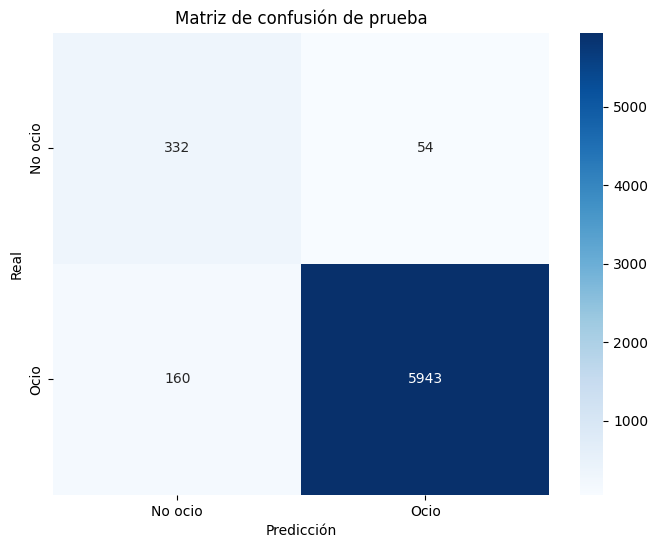

In [ ]:
cm_test = confusion_matrix(y_test, y_test_pred_base)
mostrar_matriz_confusion(cm_test, nombres_clases, title='Matriz de confusión de prueba')

### Métricas de clasificación para entrenamiento

In [ ]:
print(classification_report(y_train, y_train_pred_base, target_names=nombres_clases))

              precision    recall  f1-score   support

     No ocio       0.75      0.99      0.85      1543
        Ocio       1.00      0.98      0.99     24410

    accuracy                           0.98     25953
   macro avg       0.87      0.98      0.92     25953
weighted avg       0.98      0.98      0.98     25953



### Métricas de clasificación para prueba

In [ ]:
print(classification_report(y_test, y_test_pred_base, target_names=nombres_clases))

              precision    recall  f1-score   support

     No ocio       0.67      0.86      0.76       386
        Ocio       0.99      0.97      0.98      6103

    accuracy                           0.97      6489
   macro avg       0.83      0.92      0.87      6489
weighted avg       0.97      0.97      0.97      6489



El modelo base (con parámetros por defecto) obtiene un 87% de macro f1-score.

## Grid-Search con Logistic Regression

In [ ]:
# Pipeline con TF-IDF + Regresión logística
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced'))
])

In [ ]:
param_grid = {
    #'tfidf__max_features': [500, 1000, 3000, 5000, 7000],
    'tfidf__max_features': [5000, 7000, 9000, 10000, 15000],
    'clf__C': [0.1, 1, 10, 50, 100],
    'clf__penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(pipe_lr, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, return_train_score=True, verbose=2)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_features=5000)),
                                       ('clf',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           solver='liblinear'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10, 50, 100],
                         'clf__penalty': ['l1', 'l2'],
                         'tfidf__max_features': [5000, 7000, 9000, 10000,
                                                 15000]},
             return_train_score=True, scoring='f1_macro', verbose=2)

In [ ]:
results = grid_search.cv_results_

df_results_lr = pd.DataFrame({
    'params': results['params'],
    'mean_train_score': results.get('mean_train_score'),
    'std_train_score': results.get('std_train_score'),
    'mean_test_score': results['mean_test_score'],
    'std_test_score': results['std_test_score']
}).sort_values(by='mean_test_score', ascending=False).reset_index(drop=True)

df_results_lr

,params,mean_train_score,std_train_score,mean_test_score,std_test_score
0,"{'clf__C': 10, 'clf__penalty': 'l2', 'tfidf__m...",0.978627,0.001092,0.910078,0.003614
1,"{'clf__C': 50, 'clf__penalty': 'l2', 'tfidf__m...",0.995554,0.000576,0.906569,0.004444
2,"{'clf__C': 100, 'clf__penalty': 'l2', 'tfidf__...",0.998153,0.000219,0.905612,0.006331
3,"{'clf__C': 10, 'clf__penalty': 'l2', 'tfidf__m...",0.972426,0.001416,0.901390,0.004996
4,"{'clf__C': 1, 'clf__penalty': 'l2', 'tfidf__ma...",0.949786,0.000680,0.900930,0.005935
5,"{'clf__C': 10, 'clf__penalty': 'l2', 'tfidf__m...",0.971563,0.001305,0.896117,0.005731
6,"{'clf__C': 50, 'clf__penalty': 'l2', 'tfidf__m...",0.992672,0.000648,0.895865,0.006193
7,"{'clf__C': 50, 'clf__penalty': 'l2', 'tfidf__m...",0.991330,0.001168,0.893484,0.006339
8,"{'clf__C': 1, 'clf__penalty': 'l2', 'tfidf__ma...",0.943163,0.000837,0.892751,0.007301
9,"{'clf__C': 100, 'clf__penalty': 'l2', 'tfidf__...",0.996484,0.000396,0.891528,0.004784


In [ ]:
print(df_results_lr.iloc[:20].to_string())

                                                                 params  mean_train_score  std_train_score  mean_test_score  std_test_score
0    {'clf__C': 10, 'clf__penalty': 'l2', 'tfidf__max_features': 15000}          0.978627         0.001092         0.910078        0.003614
1    {'clf__C': 50, 'clf__penalty': 'l2', 'tfidf__max_features': 15000}          0.995554         0.000576         0.906569        0.004444
2   {'clf__C': 100, 'clf__penalty': 'l2', 'tfidf__max_features': 15000}          0.998153         0.000219         0.905612        0.006331
3    {'clf__C': 10, 'clf__penalty': 'l2', 'tfidf__max_features': 10000}          0.972426         0.001416         0.901390        0.004996
4     {'clf__C': 1, 'clf__penalty': 'l2', 'tfidf__max_features': 15000}          0.949786         0.000680         0.900930        0.005935
5     {'clf__C': 10, 'clf__penalty': 'l2', 'tfidf__max_features': 9000}          0.971563         0.001305         0.896117        0.005731
6    {'clf__C': 50, 

In [ ]:
mejores_params_lr = grid_search.best_params_
print("Mejores hiperparámetros:", mejores_params_lr)

Mejores hiperparámetros: {'clf__C': 10, 'clf__penalty': 'l2', 'tfidf__max_features': 15000}


## Entrenamiento del mejor modelo

In [ ]:
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=15000)),
    ('lr', LogisticRegression(C = 10, penalty='l2', max_iter=1000, solver='liblinear', class_weight='balanced'))
    #('tfidf', TfidfVectorizer(max_features=10000)),
    #('lr', LogisticRegression(C = 1, penalty='l2', max_iter=1000, solver='liblinear', class_weight='balanced'))
])

# Entrenar
pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=15000)),
                ('lr',
                 LogisticRegression(C=10, class_weight='balanced',
                                    max_iter=1000, solver='liblinear'))])

## Predicciones de entrenamiento y prueba

In [ ]:
y_train_pred = pipe_lr.predict(X_train)
y_test_pred = pipe_lr.predict(X_test)

## Nombres de clases

In [ ]:
nombres_clases = ['No ocio', 'Ocio']

## Matrices de confusión

In [ ]:
def mostrar_matriz_confusion(conf_matrix, class_names, title='Matriz de confusión'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

### Matriz de confusión para entrenamiento

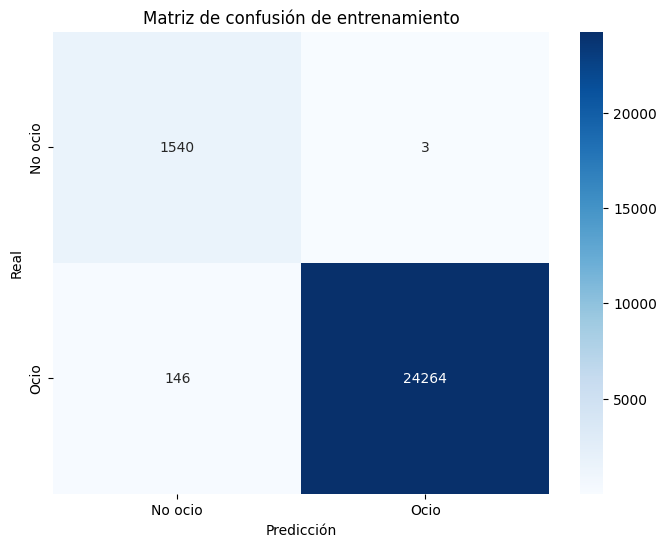

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
cm_train = confusion_matrix(y_train, y_train_pred)
mostrar_matriz_confusion(cm_train, nombres_clases, title='Matriz de confusión de entrenamiento')

### Matriz de confusión para prueba

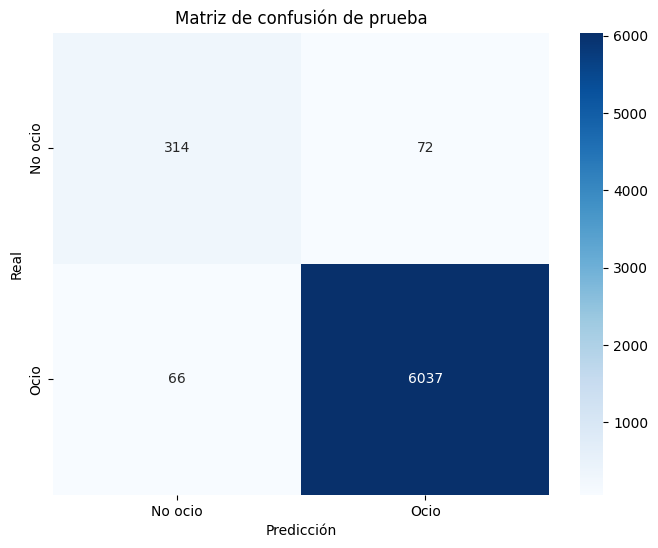

In [ ]:
cm_test = confusion_matrix(y_test, y_test_pred)
mostrar_matriz_confusion(cm_test, nombres_clases, title='Matriz de confusión de prueba')

## Métricas de clasificación para entrenamiento

In [ ]:
print(classification_report(y_train, y_train_pred, target_names=nombres_clases))

              precision    recall  f1-score   support

     No ocio       0.91      1.00      0.95      1543
        Ocio       1.00      0.99      1.00     24410

    accuracy                           0.99     25953
   macro avg       0.96      1.00      0.98     25953
weighted avg       0.99      0.99      0.99     25953



## Métricas de clasificación para prueba

In [ ]:
print(classification_report(y_test, y_test_pred, target_names=nombres_clases))

              precision    recall  f1-score   support

     No ocio       0.83      0.81      0.82       386
        Ocio       0.99      0.99      0.99      6103

    accuracy                           0.98      6489
   macro avg       0.91      0.90      0.90      6489
weighted avg       0.98      0.98      0.98      6489



## Tiempo promedio de inferencia

In [ ]:
import time

def tiempo_inferencia_promedio(textos, modelo):
    tiempos = []
    for texto in textos:
        #inicio = time.time()
        inicio = time.perf_counter()
        modelo.predict([texto])
        #fin = time.time()
        fin = time.perf_counter()
        tiempos.append(fin - inicio)
    tiempo_promedio = np.mean(tiempos)
    return tiempo_promedio

train_inference_mean = tiempo_inferencia_promedio(X_train, pipe_lr)
print(f"Tiempo de inferencia promedio: {train_inference_mean:.6f} segundos")

Tiempo de inferencia promedio: 0.001215 segundos


## Se guarda el mejor modelo

In [ ]:
from joblib import dump, load
dump(pipe_lr, 'modelo_tfidf_logreg.joblib')

['modelo_tfidf_logreg.joblib']

## Predicciones para nuevos textos

### Preprocesamiento

In [ ]:
import spacy
import unicodedata
from spacy.lang.es.stop_words import STOP_WORDS

# Cargar modelo en español de SpaCy para lematización
nlp = spacy.load('es_core_news_sm')

# Crear lista de stopwords normalizada (sin acentos)
stopwords_normalizadas = set(normalizar_texto(palabra) for palabra in STOP_WORDS)

# Función para eliminar acentos y pasar a minúsculas
def normalizar_texto(texto):
    texto = texto.lower()
    texto = unicodedata.normalize('NFD', texto).encode('ascii', 'ignore').decode('utf-8')
    return texto

def preprocesar_texto(texto):
    # Eliminar URLs
    texto = texto = re.sub(r'http\S+|www\S+|https\S+', ' ', texto)

    # Normalizar texto (minúsculas y sin acentos)
    texto_norm = normalizar_texto(texto)

    # Eliminar puntuación y caracteres no alfabéticos (conservando espacios)
    texto_norm = re.sub(r'[^a-zA-Z\s]', ' ', texto_norm)

    # Tokenizar con spaCy (sin lematizar aquí para mantener la forma limpia)
    doc = nlp(texto_norm)

    # Filtrar tokens cuyo texto normalizado está en stopwords normalizadas
    tokens_filtrados = [token.text for token in doc if token.text not in stopwords_normalizadas and token.text.strip() != '']
    return ' '.join(tokens_filtrados)
    #tokens_lematizados = [token.lemma_ for token in doc if token.lemma_ not in stopwords_normalizadas and token.lemma_.strip() != '']

    #return ' '.join(tokens_lematizados

### Predicciones

In [ ]:
texto_prueba = "La inteligencia artificial cambiará el mundo"
texto_preprocesado = preprocesar_texto(texto_prueba)

from joblib import load

# Para cargar y usar luego:
pipe_cargado = load('modelo_tfidf_logreg.joblib')
predicciones = pipe_cargado.predict([texto_preprocesado])

# Probabilidad de cada clase (array con una fila por muestra y columnas por clase)
probabilidades = pipe_cargado.predict_proba([texto_preprocesado])

# Por ejemplo, para la probabilidad de la clase positiva en clasificación binaria:
prob_clase_positiva = probabilidades[:, 1]

print("Predicciones:", predicciones[0])
print("Probabilidades de clase positiva:", prob_clase_positiva[0])

Predicciones: 1
Probabilidades de clase positiva: 0.5367368091113138


# Naive Bayes

## Grid-Search

In [ ]:
from sklearn.naive_bayes import MultinomialNB

pipe_nb = Pipeline([('tfidf', TfidfVectorizer()),
                    ('clf', MultinomialNB())])

# GridSearch para Naive Bayes
param_grid_nb = {
    'tfidf__max_features': [1000, 3000, 5000, 7000, 10000, 15000],
    'clf__alpha': [0.01, 0.1, 1]  # suavizado Laplace
}

grid_search_nb = GridSearchCV(pipe_nb, param_grid_nb, cv=5, scoring='f1_macro', n_jobs=-1)

grid_search_nb.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('clf', MultinomialNB())]),
             n_jobs=-1,
             param_grid={'clf__alpha': [0.01, 0.1, 1],
                         'tfidf__max_features': [1000, 3000, 5000, 7000, 10000,
                                                 15000]},
             scoring='f1_macro')

In [ ]:
mejores_params_nb = grid_search_nb.best_params_
print("Mejores hiperparámetros de naive bayes:", mejores_params_nb)

Mejores hiperparámetros de naive bayes: {'clf__alpha': 0.01, 'tfidf__max_features': 15000}


## Entrenamiento del mejor modelo

In [ ]:
from sklearn.naive_bayes import MultinomialNB

pipe_nb = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=15000)),
    ('clf', MultinomialNB(alpha=0.01))
])

# Entrenar
pipe_nb.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=15000)),
                ('clf', MultinomialNB(alpha=0.01))])

## Predicciones de entrenamiento y prueba

In [ ]:
y_train_pred_nb = pipe_nb.predict(X_train)
y_test_pred_nb = pipe_nb.predict(X_test)

## Nombres de clases

In [ ]:
nombres_clases = ['No ocio', 'Ocio']

## Matrices de confusión

### Matriz de confusión para entrenamiento

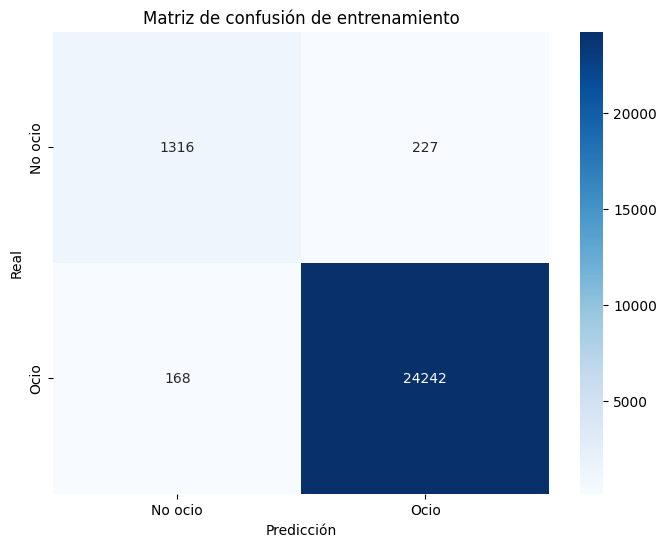

In [ ]:
cm_train_nb = confusion_matrix(y_train, y_train_pred_nb)
mostrar_matriz_confusion(cm_train_nb, nombres_clases, title='Matriz de confusión de entrenamiento')

### Matriz de confusión para prueba

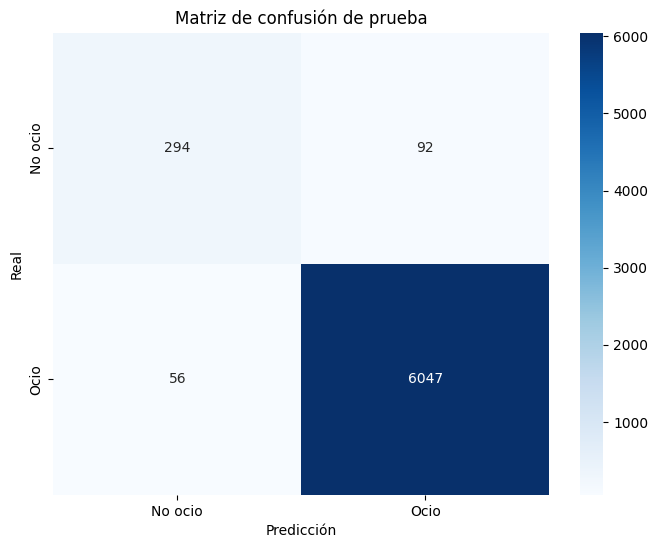

In [ ]:
cm_test_nb = confusion_matrix(y_test, y_test_pred_nb)
mostrar_matriz_confusion(cm_test_nb, nombres_clases, title='Matriz de confusión de prueba')

## Métricas de clasificación para entrenamiento

In [ ]:
print(classification_report(y_train, y_train_pred_nb, target_names=nombres_clases))

              precision    recall  f1-score   support

     No ocio       0.89      0.85      0.87      1543
        Ocio       0.99      0.99      0.99     24410

    accuracy                           0.98     25953
   macro avg       0.94      0.92      0.93     25953
weighted avg       0.98      0.98      0.98     25953



## Métricas de clasificación para prueba

In [ ]:
print(classification_report(y_test, y_test_pred_nb, target_names=nombres_clases))

              precision    recall  f1-score   support

     No ocio       0.84      0.76      0.80       386
        Ocio       0.99      0.99      0.99      6103

    accuracy                           0.98      6489
   macro avg       0.91      0.88      0.89      6489
weighted avg       0.98      0.98      0.98      6489



## Tiempo promedio de inferencia

In [ ]:
import time

def tiempo_inferencia_promedio(textos, modelo):
    tiempos = []
    for texto in textos:
        #inicio = time.time()
        inicio = time.perf_counter()
        modelo.predict([texto])
        #fin = time.time()
        fin = time.perf_counter()
        tiempos.append(fin - inicio)
    tiempo_promedio = np.mean(tiempos)
    return tiempo_promedio

train_inference_mean_nb = tiempo_inferencia_promedio(X_train, pipe_nb)
print(f"Tiempo de inferencia promedio: {train_inference_mean_nb:.6f} segundos")

Tiempo de inferencia promedio: 0.001041 segundos


# Word2vec

In [ ]:
tokenized_train = [sentence.split() for sentence in X_train]
tokenized_test = [sentence.split() for sentence in X_test]

## Entrenamiento

In [ ]:
w2v_model = Word2Vec(sentences=tokenized_train, vector_size=100, window=5, min_count=2, workers=4, sg=0)

## Vector promedio de palabras

In [ ]:
# Función para transformar cada texto en vector promedio de sus palabras
def vector_promedio(textos, modelo_w2v, size=100):
    vectors = []
    for tokens in textos:
        word_vecs = [modelo_w2v.wv[word] for word in tokens if word in modelo_w2v.wv]
        if len(word_vecs) > 0:
            vectors.append(np.mean(word_vecs, axis=0))
        else:
            vectors.append(np.zeros(size))
    return np.array(vectors)

In [ ]:
X_train_vec = vector_promedio(tokenized_train, w2v_model, 100)
X_test_vec = vector_promedio(tokenized_test, w2v_model, 100)

In [ ]:
print(f"Tamaño de embeddings de entrenamiento: {X_train_vec.shape}")
print(f"Tamaño de embeddings de prueba: {X_test_vec.shape}")

Tamaño de embeddings de entrenamiento: (25953, 100)
Tamaño de embeddings de prueba: (6489, 100)


## Grid-search

In [ ]:
logreg = LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced')

param_grid = {
    #'C': [0.01, 0.1, 1, 10, 50, 100],
    'C': [0.01, 0.1, 1, 10, 50, 100],
    'penalty': ['l1', 'l2']
}

grid_search_wv = GridSearchCV(logreg, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=3)

grid_search_wv.fit(X_train_vec, y_train)

In [ ]:
print("Mejores hiperparámetros:", grid_search_wv.best_params_)

## Entrenamiento del mejor modelo

In [ ]:
best_lr_wv = LogisticRegression(C = 0.1, penalty='l2', max_iter=1000, solver='liblinear', class_weight='balanced')
best_lr_wv.fit(X_train_vec, y_train)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   solver='liblinear')

## Predicciones de entrenamiento y prueba

In [ ]:
y_train_pred_wv = best_lr_wv.predict(X_train_vec)
y_test_pred_wv = best_lr_wv.predict(X_test_vec)

## Matrices de confusión

### Matriz de confusión para entrenamiento

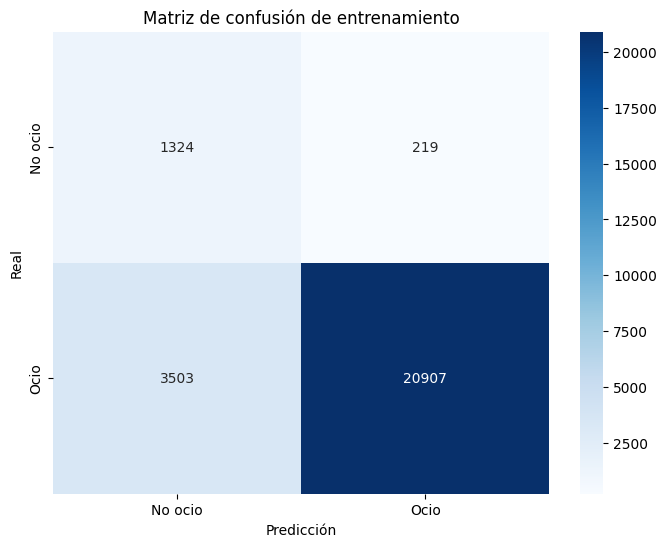

In [ ]:
cm_train_wv = confusion_matrix(y_train, y_train_pred_wv)
mostrar_matriz_confusion(cm_train_wv, nombres_clases, title='Matriz de confusión de entrenamiento')

### Matriz de confusión para prueba

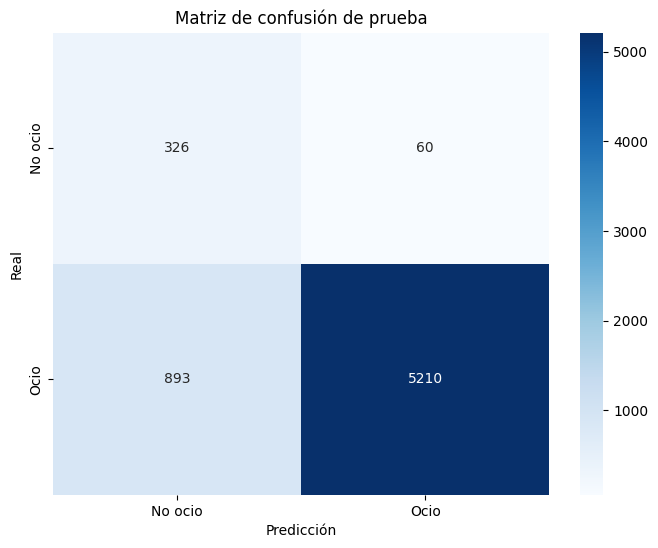

In [ ]:
cm_test_wv = confusion_matrix(y_test, y_test_pred_wv)
mostrar_matriz_confusion(cm_test_wv, nombres_clases, title='Matriz de confusión de prueba')

## Métricas de clasificación para entrenamiento

In [ ]:
print(classification_report(y_train, y_train_pred_wv, target_names=nombres_clases))

              precision    recall  f1-score   support

     No ocio       0.27      0.86      0.42      1543
        Ocio       0.99      0.86      0.92     24410

    accuracy                           0.86     25953
   macro avg       0.63      0.86      0.67     25953
weighted avg       0.95      0.86      0.89     25953



## Métricas de clasificación para prueba

In [ ]:
print(classification_report(y_test, y_test_pred_wv, target_names=nombres_clases))

              precision    recall  f1-score   support

     No ocio       0.27      0.84      0.41       386
        Ocio       0.99      0.85      0.92      6103

    accuracy                           0.85      6489
   macro avg       0.63      0.85      0.66      6489
weighted avg       0.95      0.85      0.89      6489



# Usando Sentence Transformer

In [ ]:
data_df['text_combined'] = data_df['title'] + ' ' + data_df['description'].fillna("")
data_df['label'] = data_df['leisure_label'].map({'ocio':1, 'no ocio':0})

## Separar textos de variable objetivo

In [ ]:
y = data_df['label'].values
X_orig = data_df['text_combined'].values

## Particionamiento de textos

In [ ]:
from sklearn.model_selection import train_test_split
X_train_st, X_test_st, y_train_st, y_test_st = train_test_split(X_orig, y, test_size=0.2, random_state=42, stratify=y)

print(f'Tamaño del conjunto de datos de entrenamiento: {X_train_st.shape}')
print(f'Tamaño del conjunto de datos de prueba: {X_test_st.shape}')

Tamaño del conjunto de datos de entrenamiento: (25953,)
Tamaño del conjunto de datos de prueba: (6489,)


## Modelo multilingue

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer('intfloat/multilingual-e5-small')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

## Función para dividir el texto en chunks

In [ ]:
# Función para dividir el texto en chunks según máximo tokens aproximado
def chunk_text(text, max_tokens=128):
    words = text.split()
    chunks = []
    for i in range(0, len(words), max_tokens):
        chunk = " ".join(words[i:i+max_tokens])
        chunks.append(chunk)
    return chunks

chunk_text(data_df['text_combined'].iloc[0], max_tokens= 500)

['Ovi x Natanael Cano x Aleman x Big Soto - Vengo De Nada [Official Video] Vengo De Nada - Ovi x Natanael Cano x Aleman x Big SotoDirected by Lalo The GiantExecutive Producer Jimmy Humildehttp://Instagram.com/Ovi_Oficialhttp://Instagram.com/Natanael_Canohttp://Instagram.com/mxalemanmxhttp://Instagram.com/BigSotorius_x000D_Suscríbete: http://Rancho.lnk.to/RHYoutubeEscucha Vengo De Nada aquí:http://Rancho.lnk.to/VengoDeNada 🎶Paginas Oficiales De Rancho HumildeSpotify: http://Rancho.lnk.to/RHSpotifyInstagram: http://Rancho.lnk.to/InstagramFacebook: http://Rancho.lnk.to/RHFacebook🎧Spotify Playlists:➤ 💪Entre Acordeones: http://Rancho.lnk.to/SpotifyPlaylist1➤ 🚬 420 Smoke Me Out: http://Rancho.lnk.to/SpotifySMOYouTube Playlists 📢📢 | Corridos 2020Natanael Cano: http://Rancho.lnk.to/NCPlaylistLegado 7: http://Rancho.lnk.to/L7PlaylistFuerza Regida: http://Rancho.lnk.to/FRPlaylistEl De La Guitarra: http://Rancho.lnk.to/EdlgPlaylistGrupo Codiciado: http://Rancho.lnk.to/GCPlaylistLos Hijos De Garci

## Obtener embeddings en lotes y combinarlos

In [ ]:
# Función para obtener embeddings en lotes y combinarlos (promedio) para cada texto
def get_batch_embeddings(texts, embedder, max_tokens=128, batch_size=32):
    all_chunks = []
    chunk_map = []  # Asocia cada chunk con índice original del texto

    for idx, text in enumerate(texts):
        chunks = chunk_text(text, max_tokens)
        all_chunks.extend(chunks)
        chunk_map.extend([idx] * len(chunks))

    # Obtener embeddings en lotes de todos los chunks
    chunk_embeddings = embedder.encode(all_chunks, batch_size=batch_size, convert_to_numpy=True, show_progress_bar=True)

    # Combinar embeddings de chunks por texto con promedio
    embeddings_by_text = [[] for _ in range(len(texts))]
    for emb, idx in zip(chunk_embeddings, chunk_map):
        embeddings_by_text[idx].append(emb)

    combined_embeddings = np.array([np.mean(chunk_embs, axis=0) for chunk_embs in embeddings_by_text])
    return combined_embeddings

In [ ]:
import torch
from sentence_transformers import SentenceTransformer

# Check if GPU is available and set device accordingly
device = 'cuda' if torch.cuda.is_available() else 'cpu'
embedding_model = SentenceTransformer('intfloat/multilingual-e5-small', device=device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

In [ ]:
max_context_tokens = 500
batch_size = 32
X_train_embed = get_batch_embeddings(X_train_st, embedding_model , max_tokens=max_context_tokens, batch_size=batch_size)

Batches:   0%|          | 0/823 [00:00<?, ?it/s]

In [ ]:
X_test_embed = get_batch_embeddings(X_test_st, embedding_model , max_tokens=max_context_tokens, batch_size=batch_size)

Batches:   0%|          | 0/207 [00:00<?, ?it/s]

In [ ]:
print(f"Tamaño de embeddings de entrenamiento: {X_train_embed.shape}")
print(f"Tamaño de embeddings de prueba: {X_test_embed.shape}")

Tamaño de embeddings de entrenamiento: (25953, 384)
Tamaño de embeddings de prueba: (6489, 384)


## Entrenamiento del mejor modelo

In [ ]:
best_lr_st = LogisticRegression(C = 50, penalty='l2', max_iter=1000, solver='liblinear', class_weight='balanced')
best_lr_st.fit(X_train_embed, y_train_st)

LogisticRegression(C=50, class_weight='balanced', max_iter=1000,
                   solver='liblinear')

## Predicciones de entrenamiento y prueba

In [ ]:
y_train_pred_st = best_lr_st.predict(X_train_embed)
y_test_pred_st = best_lr_st.predict(X_test_embed)

## Matrices de confusión

### Matriz de confusión para entrenamiento

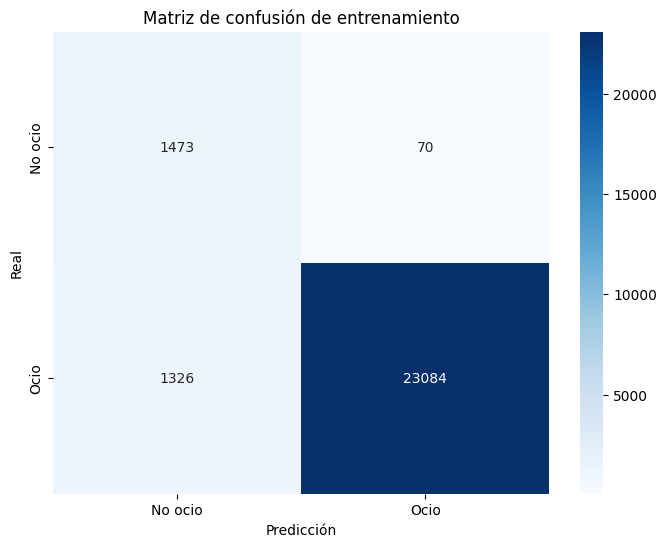

In [ ]:
cm_train_st = confusion_matrix(y_train_st, y_train_pred_st)
mostrar_matriz_confusion(cm_train_st, nombres_clases, title='Matriz de confusión de entrenamiento')

### Matriz de confusión para prueba

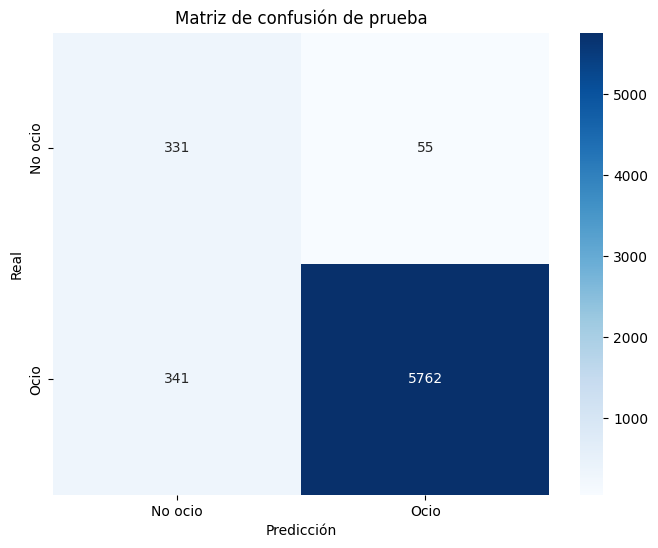

In [ ]:
cm_test_st = confusion_matrix(y_test_st, y_test_pred_st)
mostrar_matriz_confusion(cm_test_st, nombres_clases, title='Matriz de confusión de prueba')

## Métricas de clasificación para entrenamiento

In [ ]:
print(classification_report(y_train_st, y_train_pred_st, target_names=nombres_clases))

              precision    recall  f1-score   support

     No ocio       0.53      0.95      0.68      1543
        Ocio       1.00      0.95      0.97     24410

    accuracy                           0.95     25953
   macro avg       0.76      0.95      0.82     25953
weighted avg       0.97      0.95      0.95     25953



## Métricas de clasificación para prueba

In [ ]:
print(classification_report(y_test_st, y_test_pred_st, target_names=nombres_clases))

              precision    recall  f1-score   support

     No ocio       0.49      0.86      0.63       386
        Ocio       0.99      0.94      0.97      6103

    accuracy                           0.94      6489
   macro avg       0.74      0.90      0.80      6489
weighted avg       0.96      0.94      0.95      6489

